# 0. Import Packages and Modules

In [1]:
%%capture
import numpy as np
import time
from PDE.pde_model import PDE
from PDE.pde_solver import solve_pde
from PDE.pde_controller import solve_kernel
from plot import plot_pde, plot_kernel, plot_lambda, plot_observer_error, plot_U, plot_learning_error
from DeepONet.generate_data import generate_lambda_dataset, generate_kernel_dataset
from DeepONet.training import train_operator, load_operator, compute_k_hat, compute_k_hats

---

# 1. Open Loop PDE

Consider parabolic PDE systems of the form:

$
\begin{align}
u_t(x,t) &= u_{xx}(x,t) + \lambda(x)\,u(x,t), \quad x \in (0,1), \\
u(0,t) &= 0, \\
u(1,t) &= 0.
\end{align}
$

## 1-1. Define PDE <a id="define-pdes"></a>

In the paper, the open-loop PDE is solved for two different $\lambda(x)$, defined as:

$
\begin{align}
\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right), \quad \lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right).
\end{align}
$

In [2]:
# Define PDE for λ(x) = 50cos(5ccos^-1(x))
def lambda1(x): return 50*np.cos(5*np.arccos(x))
pde1 = PDE(lam=lambda1)

# Define PDE for λ(x) = 50cos(8ccos^-1(x))
def lambda2(x): return 50*np.cos(8*np.arccos(x))
pde2 = PDE(lam=lambda2)

## 1-2. Solve Open Loop PDE

The finite difference scheme is used to solve the PDE:

$
\begin{align}
u_i^{\,n+1} = u_i^n + \Delta t \left( 
\frac{u_{i+1}^n - 2 u_i^n + u_{i-1}^n}{h^2} 
+ \lambda_i \, u_i^n 
\right),
\quad i = 1, 2, \dots, N-1, \; n = 0,1,\dots, N_t-1.
\end{align}
$

In [3]:
# Solve open loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x))
u1_ol, _ = solve_pde(pde=pde1)

# Solve open loop PDE u(x,t) for λ(x) = 50cos(8ccos^-1(x))
u2_ol, _ = solve_pde(pde=pde2)

## 1-3. Plot Open Loop Results

### 1-3-1. Plot λ(x)

My results:

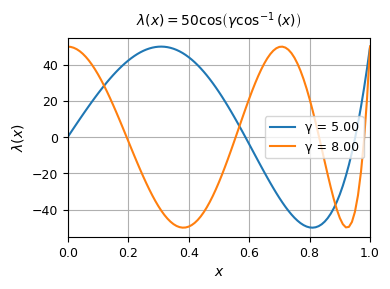

In [4]:
# Plot λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_lambda(x=pde1.x, lam=np.vstack([lambda1(pde1.x), lambda2(pde2.x)]), gamma=np.array([5, 8]), title=r'$\lambda(x)=50\cos\!\left(\gamma\cos^{-1}(x)\right)$')

Paper Results:

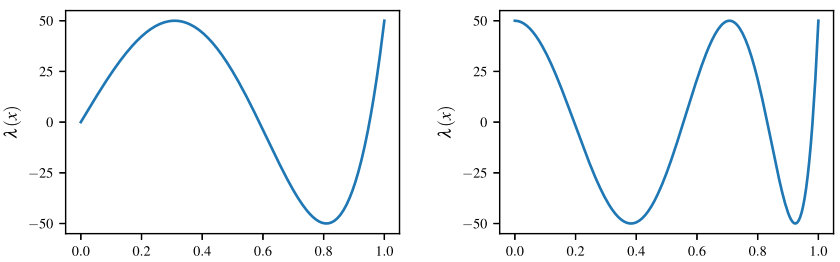

### 1-3-2. Plot Open Loop PDEs

My Results:

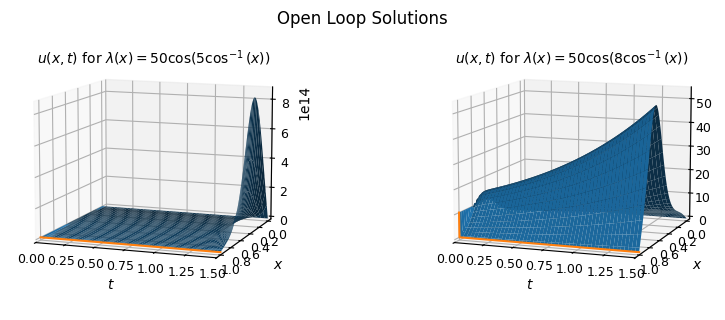

In [5]:
# Plot open loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_pde(x=pde1.x, t=pde1.t, u=[u1_ol, u2_ol], fig_title=r'Open Loop Solutions' , title=[r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$'], z_title=[r'', r''], cols=2)

Paper results:

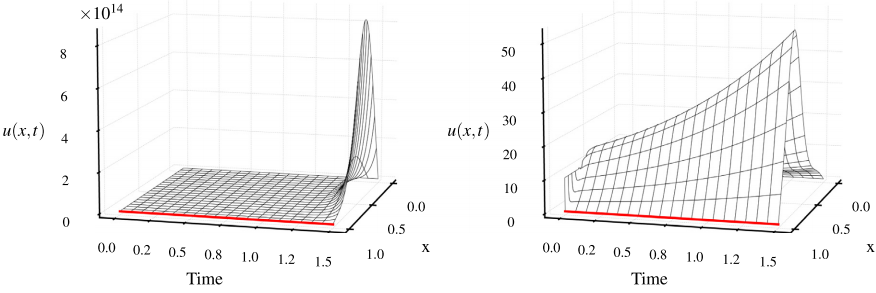

---

# 2. Closed-Loop PDE (Backstepping Control)

Consider parabolic PDE systems of the form:

$
\begin{align}
u_t(x,t) &= u_{xx}(x,t) + \lambda(x)\,u(x,t), \quad x \in (0,1), \\
u(0,t) &= 0, \\
u(1,t) &= U(t).
\end{align}
$

where

$
\begin{align}
U(t) = \int_0^1 k(1, y)\, u(y, t) \, dy
\end{align}
$

## 2-1. Define PDEs

We can use defined PDEs in [Section 1-1](#define-pdes).

## 2-2. Compute Kernel

To compute the kernel, we need to solve the following kernel PDE:

$
\begin{align}
k_{xx}(x, y) - k_{yy}(x, y) &= \lambda(y) k(x, y), \quad \forall (x, y) \in \check{T}, \\
k(x, 0) &= 0, \\
k(x, x) &= -\frac{1}{2} \int_0^x \lambda(y) \, dy.
\end{align}
$

The finite difference scheme is used to solve the kernel PDE:

$
\begin{align}
k_{i+1,j} &= -k_{i-1,j} + k_{i,j+1} + k_{i,j-1} + h^2 \lambda_j \frac{k_{i,j+1} + k_{i,j-1}}{2}, \\
k_{i+1,i} &= k_{i,i} + \frac{h^2}{2} \lambda_i, \\
k_{i+1,i+1} &= k_{i,i} - \frac{h}{4} (\lambda_i + \lambda_{i+1}), \quad k_{j+1,1} = 0,
\end{align}
$

with

$
\begin{align}
k_j^i = k((i-1)h, (j-1)h), \quad i = 2, \dots, N, \quad j = 2, \dots, i-1, \quad
\lambda_i = \bar{\lambda}((i-1)h), \quad h = \frac{1}{N}.
\end{align}
$

In [6]:
# Solve kernel PDE for λ(x) = 50cos(5ccos^-1(x))
k1 = solve_kernel(lam=lambda1, nx=pde1.nx)

# Solve kernel PDE for λ(x) = 50cos(8ccos^-1(x))
k2 = solve_kernel(lam=lambda2, nx=pde2.nx)

## 2-3. Solve Closed Loop PDE

In [7]:
# Solve closed loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x))
u1_cl, _ = solve_pde(pde=pde1, k=k1)

# Solve closed loop PDE u(x,t) for λ(x) = 50cos(8ccos^-1(x))
u2_cl, _ = solve_pde(pde=pde2, k=k2)

## 2-4. Plot Closed Loop Results

### 2-4-1. Plot Kernels

My Results:

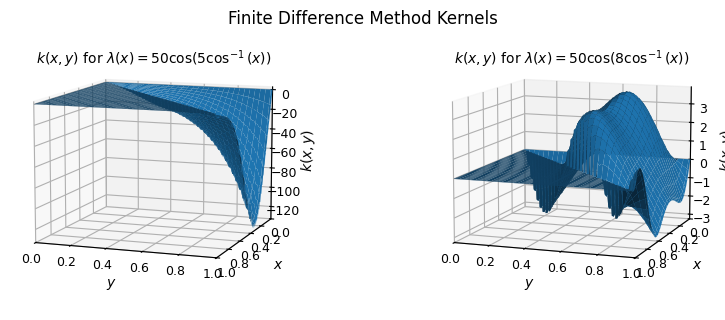

In [8]:
# Plot kernels for λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_kernel(x=pde1.x, k=[k1, k2], fig_title=r'Finite Difference Method Kernels', title=[r'$k(x,y)$ for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', r'$k(x,y)$ for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$'], z_title=[r'$k(x,y)$', r'$k(x,y)$'], cols=2)

Paper Results:

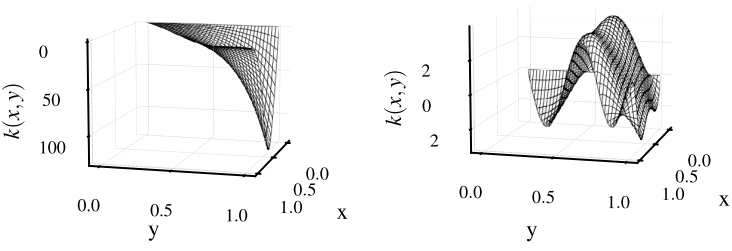

### 2-4-2. Plot Closed Loop PDEs

My Results:

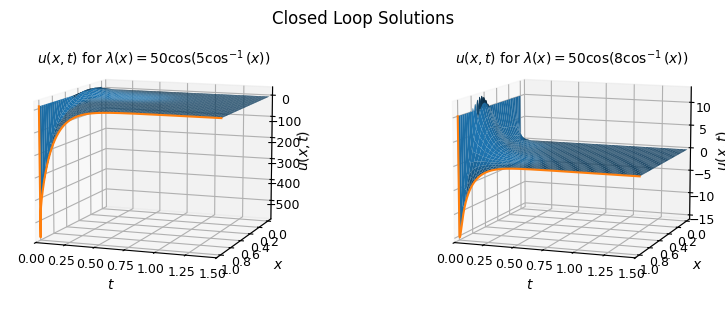

In [9]:
# Plot closed loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_pde(x=pde1.x, t=pde1.t, u=[u1_cl, u2_cl], fig_title=r'Closed Loop Solutions', title=[r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$'], z_title=[r'$u(x,t)$', r'$u(x,t)$'], cols=2)

Paper Results:

The paper does not include results for the closed-loop solution when the kernel is computed using the finite difference method. It only includes closed-loop results when the kernel is computed using neural operators, which is the main contribution of the paper.

---

# 3. Observer Design (Backstepping Observer)

PDE:

$
\begin{align}
u_t(x,t) &= u_{xx}(x,t) + \lambda(x)\,u(x,t), \quad x \in (0,1), \\
u(0,t) &= 0, \\
u(1,t) &= U(t).
\end{align}
$

Backstepping observer:

$
\begin{align}
\hat{u}_t(x,t) &= \hat{u}_{xx}(x,t) + \lambda(x)\hat{u}(x,t) 
+ k(1,x)\bigl[u_x(1,t) - \hat{u}_x(1,t)\bigr], \\
\hat{u}(0,t) &= 0, \\
\hat{u}(1,t) &= U(t).
\end{align}
$

## 3-1. Define PDE

$
\lambda(x) = 20 \cos(5 \cos^{-1}(x)), \; U(t) = 10 \cos(2\pi t) + 7 \sin(16 t)
$

In [10]:
# Define PDE for λ(x) = 20cos(5ccos^-1(x)) and U(t) = 10cos(2πt)+7sin(16t)
def lambda3(x): return 20*np.cos(5*np.arccos(x))
def u1t_3(t): return 10*np.cos(np.pi*2*t)+7*np.sin(16*t)
pde3 = PDE(lam=lambda3, u1t=u1t_3, T=3)

## 3-2. Solve Open Loop PDE

In [11]:
u3_ol, _ = solve_pde(pde=pde3)

## 3-3. Solve Open Loop Observed PDE

In [12]:
# Solve kernel PDE for λ(x) = 50cos(5ccos^-1(x))
k3 = solve_kernel(lam=lambda3, nx=pde3.nx)

# Solve open loop observed PDE u_hat(x,t)
_, u3_ol_hat = solve_pde(pde=pde3, u_hatx0=20, l=k3[-1, :])

## 3-4. Plot Observation Results

My Results:

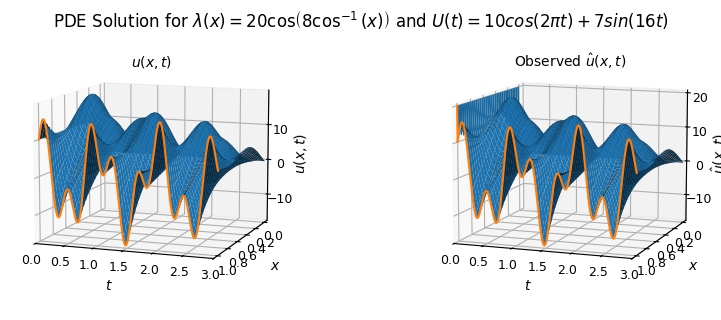

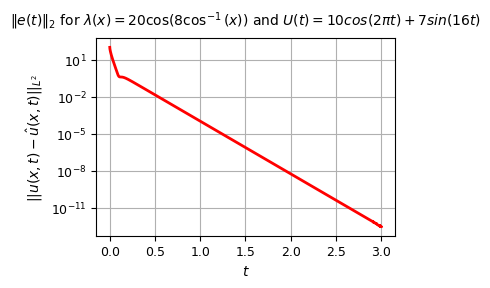

In [13]:
# Plot closed loop PDE u(x,t) and observed PDE u_hat(x,t) for λ(x) = 20cos(5ccos^-1(x)) and U(t) = 10cos(2πt)+7sin(16t)
plot_pde(x=pde3.x, t=pde3.t, u=[u3_ol, u3_ol_hat], fig_title=r'PDE Solution for $\lambda(x)=20\cos\!\left(8\cos^{-1}(x)\right)$ and $U(t)=10cos(2\pi t)+7sin(16t)$', title=[r'$u(x,t)$', r'Observed $\hat{u}(x,t)$'], z_title=[r'$u(x,t)$', r'$\hat{u}(x,t)$'], cols=2)

# Plot Observation error
e3 = u3_ol - u3_ol_hat
plot_observer_error(t=pde3.t, e=e3, title=r'$\|e(t)\|_2$ for $\lambda(x)=20\cos\!\left(8\cos^{-1}(x)\right)$ and $U(t)=10cos(2\pi t)+7sin(16t)$')

Paper Results:

The paper does not include results for the observed solution when the kernel is computed using the finite difference method. It only includes observed solution results when the kernel is computed using neural operators, which is the main contribution of the paper.

---

# 4. Training Kernel Operator

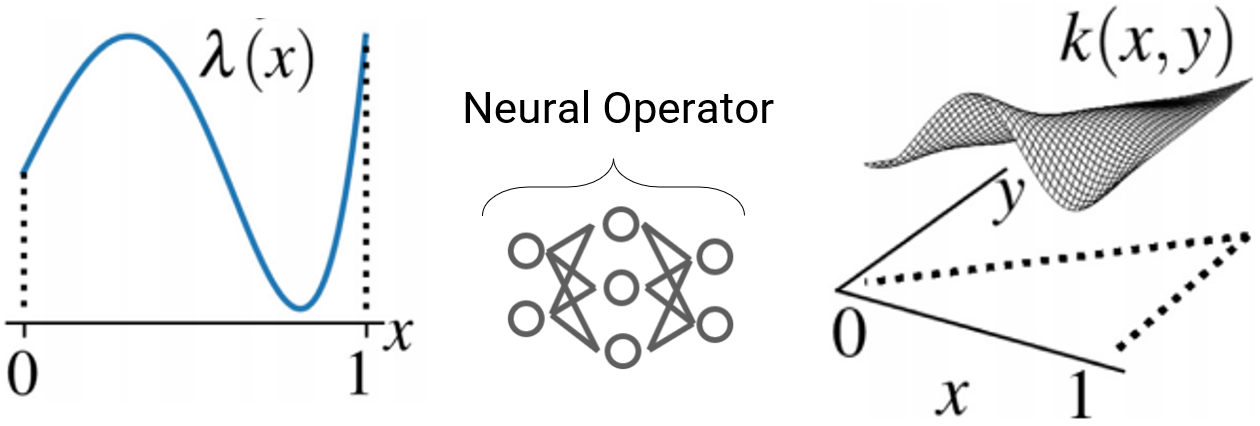

## 4-1. Create Dataset

$
\begin{align}
\lambda(x) = 50 \cos\!\left(\gamma \cos^{-1}(x)\right), 
\qquad \gamma \sim Uniform(4,9).
\end{align}
$

In [14]:
# Sample dataset λ(x) = 50cos(γccos^-1(x))
x, lam_dataset, gammas = generate_lambda_dataset(samples=6, nx=101)

# Sample dataset k(x,y)
k_dataset = generate_kernel_dataset(lam_dataset=lam_dataset)

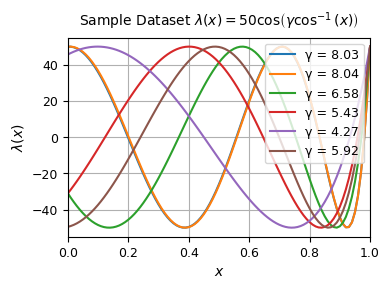

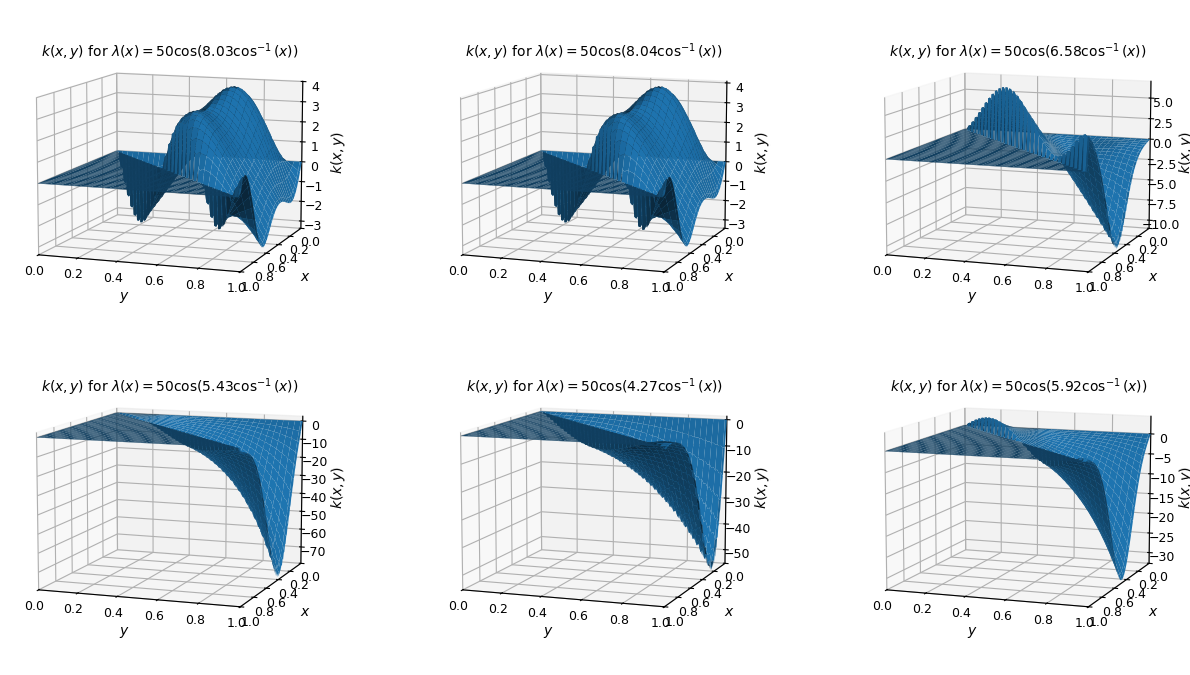

In [15]:
# Plot sample dataset λ(x) = 50cos(γccos^-1(x))
plot_lambda(x=x,  lam=lam_dataset, gamma=gammas, title=r'Sample Dataset $\lambda(x)=50\cos\!\left(\gamma\cos^{-1}(x)\right)$')

# Plot sample dataset k(x,y)
plot_kernel(x=x, k=k_dataset, fig_title='', title=[rf"$k(x,y)$ for $\lambda(x)=50\cos\!\left({g:.2f}\cos^{{-1}}(x)\right)$" for g in gammas], z_title=[r'$k(x,y)$', r'$k(x,y)$', r'$k(x,y)$', r'$k(x,y)$', r'$k(x,y)$', r'$k(x,y)$'], cols=3)

## 4-2. Training Operator

In [16]:
# Training operator for small sample and simple network
Operator = train_operator(x=x, lam_dataset=lam_dataset, k_dataset=k_dataset, samples=6, nx=101, trunk_layers=[16, 32, 32], iterations=100)

Compiling model...
'compile' took 2.402595 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [7.64e+01]    [3.77e+01]    [1.03e+00]    
50        [1.53e+01]    [2.05e+01]    [7.57e-01]    
100       [5.04e+00]    [2.44e+01]    [8.27e-01]    

Best model at step 100:
  train loss: 5.04e+00
  test loss: 2.44e+01
  test metric: [8.27e-01]

'train' took 16.565591 s



## 4-3. Use Operator

In [17]:
# Use operator for compute kernel for λ(x) = 50cos(5ccos^-1(x))
k1_hat = compute_k_hat(lam=lambda1, model=Operator, nx=pde1.nx)

# Use operator for compute kernel for λ(x) = 50cos(8ccos^-1(x))
k2_hat = compute_k_hat(lam=lambda2, model=Operator, nx=pde2.nx)

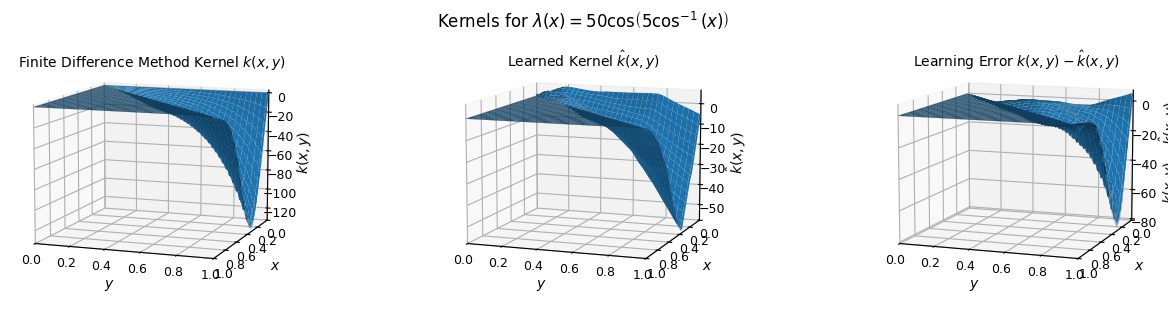

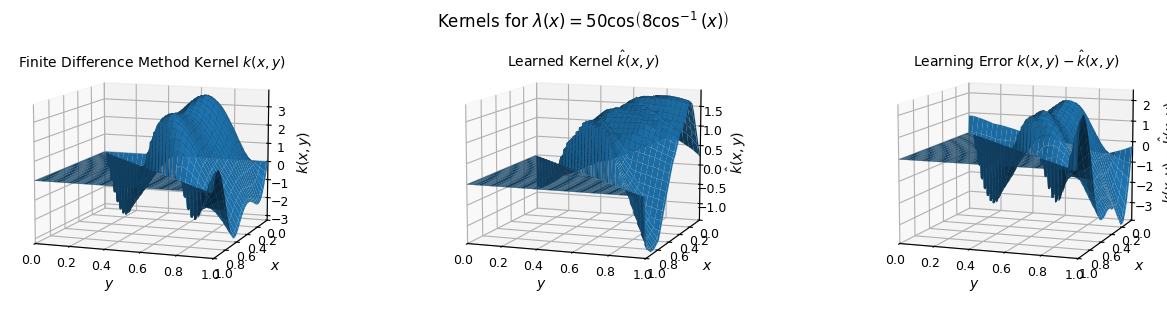

In [18]:
# Plot kernel and it's prediction for λ(x) = 50cos(5ccos^-1(x))
plot_kernel(x, k=[k1, k1_hat, k1-k1_hat], fig_title=r'Kernels for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', title=[r'Finite Difference Method Kernel $k(x,y)$', r'Learned Kernel $\hat{k}(x,y)$', r'Learning Error $k(x,y)-\hat{k}(x,y)$'], z_title=[r'$k(x,y)$', r'$\hat{k}(x,y)$', r'$k(x,y)-\hat{k}(x,y)$'], cols=3)

# Plot kernel and it's prediction for λ(x) = 50cos(8ccos^-1(x))
plot_kernel(x, k=[k2, k2_hat, k2-k2_hat], fig_title=r'Kernels for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$', title=[r'Finite Difference Method Kernel $k(x,y)$', r'Learned Kernel $\hat{k}(x,y)$', r'Learning Error $k(x,y)-\hat{k}(x,y)$'], z_title=[r'$k(x,y)$', r'$\hat{k}(x,y)$', r'$k(x,y)-\hat{k}(x,y)$'], cols=3)

## 4-4. Use Large Sample Complex Operator

In [19]:
# Load the trained operator trained on 1,000 samples with a more complex structure
Operator = load_operator(nx=101, trunk_layers=[128, 256, 256], path="DeepONet/Operator.pth-1000.pt")

Compiling model...
'compile' took 0.000562 s



In [20]:
# Use Complex operator for compute kernel for λ(x) = 50cos(5ccos^-1(x))
k1_hat = compute_k_hat(lam=lambda1, model=Operator, nx=pde1.nx)

# Use Complex operator for compute kernel for λ(x) = 50cos(5ccos^-1(x))
k2_hat = compute_k_hat(lam=lambda2, model=Operator, nx=pde2.nx)

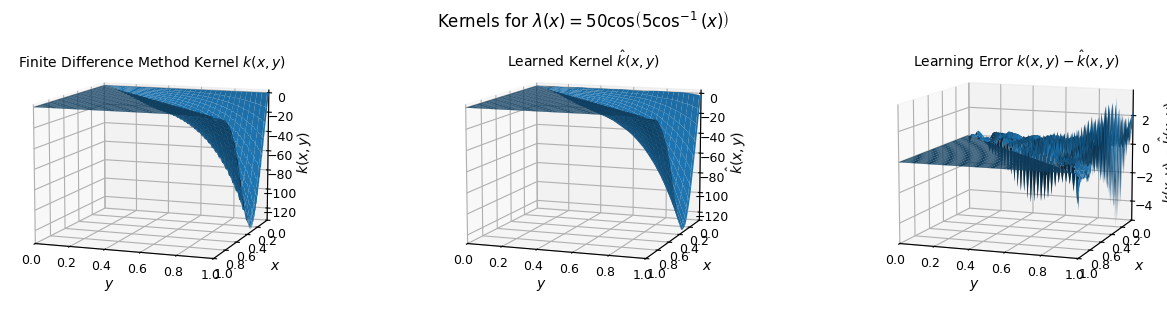

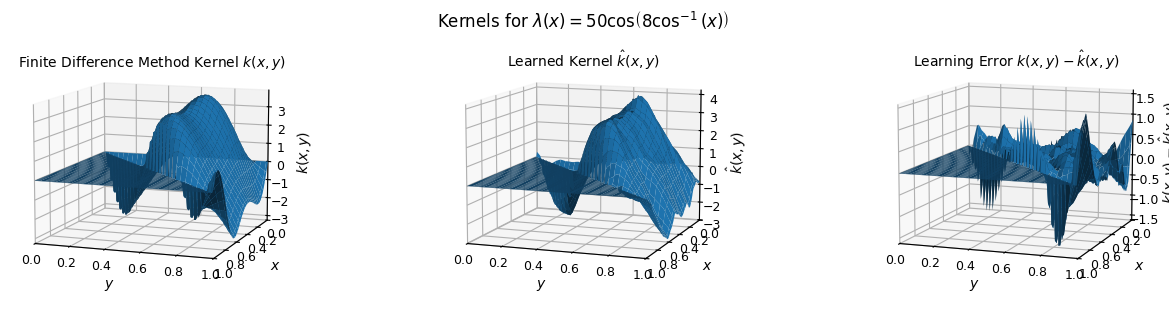

In [21]:
# Plot kernel and it's prediction for λ(x) = 50cos(5ccos^-1(x))
plot_kernel(x=x, k=[k1, k1_hat, k1-k1_hat], fig_title=r'Kernels for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', title=[r'Finite Difference Method Kernel $k(x,y)$', r'Learned Kernel $\hat{k}(x,y)$', r'Learning Error $k(x,y)-\hat{k}(x,y)$'], z_title=[r'$k(x,y)$', r'$\hat{k}(x,y)$', r'$k(x,y)-\hat{k}(x,y)$'], cols=3)

# Plot kernel and it's prediction for λ(x) = 50cos(8ccos^-1(x))
plot_kernel(x=x, k=[k2, k2_hat, k2-k2_hat], fig_title=r'Kernels for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$', title=[r'Finite Difference Method Kernel $k(x,y)$', r'Learned Kernel $\hat{k}(x,y)$', r'Learning Error $k(x,y)-\hat{k}(x,y)$'], z_title=[r'$k(x,y)$', r'$\hat{k}(x,y)$', r'$k(x,y)-\hat{k}(x,y)$'], cols=3)

## 4-5. Compare Speed

My result:

In [22]:
x, lam_dataset, gammas = generate_lambda_dataset(samples=1000, nx=101)

In [23]:
start = time.perf_counter()
for i in range(1000):
    lam = lam_dataset[i]
    def lam_func(x, lam=lam): return lam
    _ = solve_kernel(lam_func, nx=101)
analytical = time.perf_counter() - start

In [24]:
start = time.perf_counter()
compute_k_hats(lam_dataset=lam_dataset, model=Operator, nx=101, samples=1000)
learned = time.perf_counter() - start

In [25]:
print(f"Speedups: {analytical/learned:.2f}")

Speedups: 9.17


Paper result:

With the learned neural operator, we achieve speedups on the magnitude of $10^3$ compared to an efficient finite difference implementation.

---

# 5. Use Learned kernel for Backstepping Control

PDE:

$
\begin{align}
u_t(x,t) &= u_{xx}(x,t) + \lambda(x)\,u(x,t), \quad x \in (0,1), \\
u(0,t) &= 0, \\
u(1,t) &= U(t).
\end{align}
$

where

$
\begin{align}
U(t) = \int_0^1 \hat{k}(1, y)\, u(y, t) \, dy
\end{align}
$

## 5-1. Solve Closed Loop PDE

In [26]:
# Solve closed loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x))
u1_no_cl, _ = solve_pde(pde=pde1, k=k1_hat)

# Solve closed loop PDE u(x,t) for λ(x) = 50cos(8ccos^-1(x))
u2_no_cl, _ = solve_pde(pde=pde2, k=k2_hat)

## 5-2. Plot Closed Loop Results

My Results:

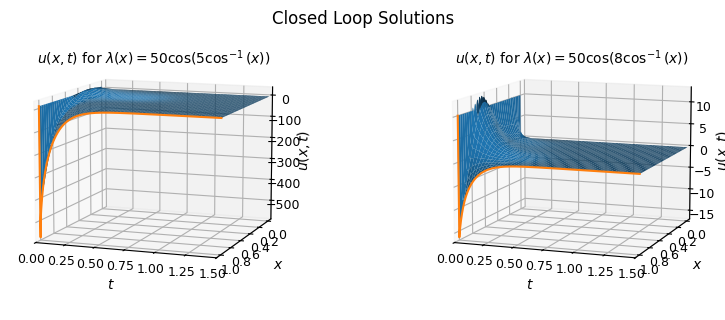

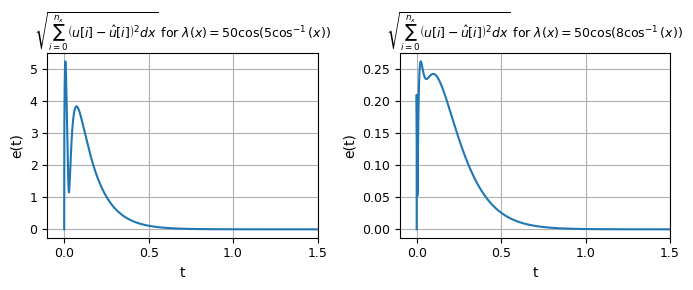

In [27]:
from plot import plot_pde, plot_kernel, plot_lambda, plot_observer_error, plot_U, plot_learning_error

# Plot closed loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_pde(x=pde1.x, t=pde1.t, u=[u1_no_cl, u2_no_cl], fig_title=r'Closed Loop Solutions', title=[r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$'], z_title=[r'$u(x,t)$', r'$u(x,t)$'], cols=2)

# Plot Learning error
plot_learning_error(U1=u1_cl, U1_hat=u1_no_cl, U2=u2_cl, U2_hat=u2_no_cl, nx=pde1.nx, t=pde1.t)

Paper Results:

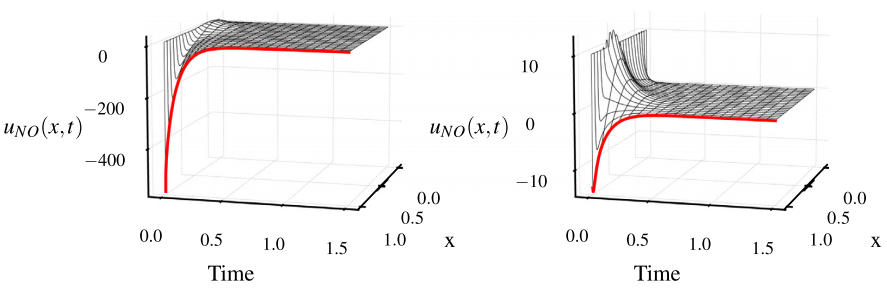

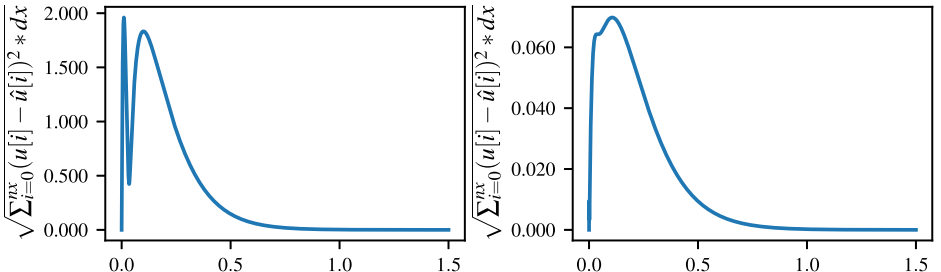

---

# 6. Use Learned kernel for Backstepping Observation

PDE:

$
\begin{align}
u_t(x,t) &= u_{xx}(x,t) + \lambda(x)\,u(x,t), \quad x \in (0,1), \\
u(0,t) &= 0, \\
u(1,t) &= U(t).
\end{align}
$

Backstepping observer:

$
\begin{align}
\hat{u}_t(x,t) &= \hat{u}_{xx}(x,t) + \lambda(x)\hat{u}(x,t) 
+ \hat{k}(1,x)\bigl[u_x(1,t) - \hat{u}_x(1,t)\bigr], \\
\hat{u}(0,t) &= 0, \\
\hat{u}(1,t) &= U(t).
\end{align}
$

## 6-1. Solve Open Loop Observed PDE

In [28]:
# Use operator for compute kernel for λ(x) = 50cos(5ccos^-1(x))
k3_hat = compute_k_hat(lam=lambda3, model=Operator, nx=pde3.nx)

# Solve open loop observed PDE u_hat(x,t)
_, u3_on_ol_hat = solve_pde(pde=pde3, u_hatx0=20, l=k3[-1, :])

## 6-2. Plot Observation Results

My Results:

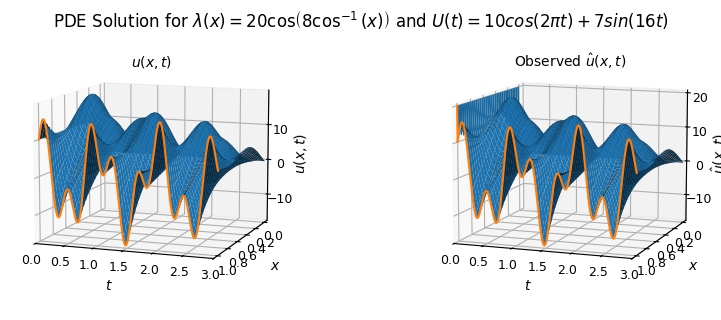

In [29]:
# Plot closed loop PDE u(x,t) and observed PDE u_hat(x,t) for λ(x) = 20cos(5ccos^-1(x)) and U(t) = 10cos(2πt)+7sin(16t)
plot_pde(x=pde3.x, t=pde3.t, u=[u3_ol, u3_on_ol_hat], fig_title=r'PDE Solution for $\lambda(x)=20\cos\!\left(8\cos^{-1}(x)\right)$ and $U(t)=10cos(2\pi t)+7sin(16t)$', title=[r'$u(x,t)$', r'Observed $\hat{u}(x,t)$'], z_title=[r'$u(x,t)$', r'$\hat{u}(x,t)$'], cols=2)

Paper Results:


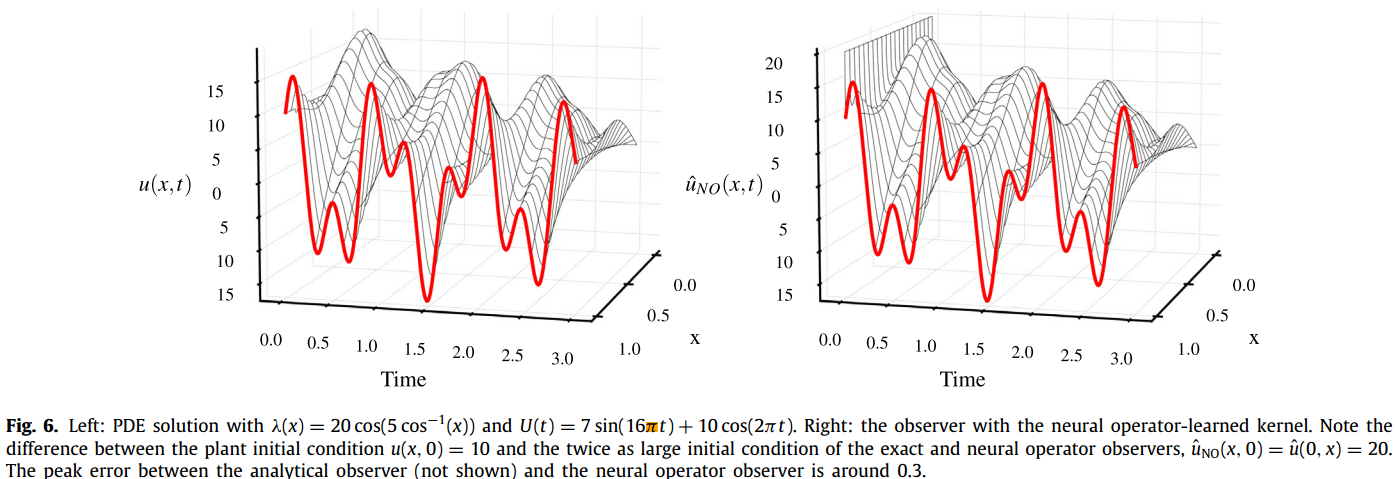

## 6-3. Paper Typo Mistake

Paper input: $U(t) = 10 \cos(2\pi t) + 7 \sin(16\textcolor{orange}{\pi} t)$

Correct input: $U(t) = 10 \cos(2\pi t) + 7 \sin(16 t)$

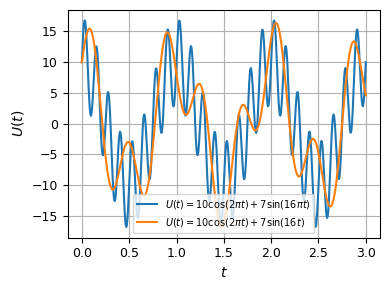

In [30]:
import numpy as np
from plot import plot_pde, plot_kernel, plot_lambda, plot_observer_error, plot_U, plot_learning_error
# U(t) = 10cos(2πt)+7sin(16πt)
def U_wrong(t): return 10*np.cos(np.pi*2*t)+7*np.sin(16*np.pi*t)
    
# U(t) = 10cos(2πt)+7sin(16t)
def U_correct(t): return 10*np.cos(np.pi*2*t)+7*np.sin(16*t)

plot_U(U=[U_wrong, U_correct], labels=[r'$U(t)=10 \cos(2\pi t)+7\sin(16\pi t)$', r'$U(t)=10 \cos(2\pi t)+7\sin(16 t)$'], title="")